In [2]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

from src.config import Configuration
CONFIG = Configuration()

# Test

In [3]:
import os
import cv2
from src.model import load_cascade, CascadeClassifier

cascade_path = os.path.join(CONFIG.computed_haar_cascades, 'haar_cascade_stage_10_fpr_0.0009.xml')
cascade = load_cascade(cascade_path)
CONFIG.crop_size = max(cascade.height, cascade.width)
classifier = CascadeClassifier(CONFIG, cascade)

Loading Haar cascade from: ../models/haar_cascades_computed/haar_cascade_stage_10_fpr_0.0009.xml


In [4]:
from src.data import get_image_crops_from_list

from maikol_utils.file_utils import list_dir_files

all_crops, cn = list_dir_files(CONFIG.no_facescrops_path)
test_faces, tn = list_dir_files(CONFIG.faces_test_path)
print(f"Total crops in no_facescrops directory: {cn}")
print(f"Total crops in faces_test directory: {tn}")




/home/turbotowerlnx/miniconda3/envs/BIOM_env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Total crops in no_facescrops directory: 100000
Total crops in faces_test directory: 8092


In [16]:
from tqdm import tqdm

all_fps, total_candidates = [], 0
for img_path in tqdm(all_crops):  # Test on the first 5 images
    fps, candidates = classifier.predict_no_merge(img_path=img_path, return_candidate_count=True)
    all_fps.extend(fps)
    total_candidates += candidates

print(f"Number of candidates: {total_candidates}")
print(f"Number of detections: {len(all_fps)}")
print(f"False Positive Rate: {len(all_fps) / total_candidates:.6f}")

  0%|          | 0/100000 [00:00<?, ?it/s]

100%|██████████| 100000/100000 [00:05<00:00, 19814.47it/s]

Number of candidates: 100000
Number of detections: 2161
False Positive Rate: 0.021610


In [20]:
from tqdm import tqdm

all_faces, total_candidates, right_predictions = [], 0, 0
for img_path in tqdm(test_faces):  # Test on the first 5 images
    faces, candidates = classifier.predict_no_merge(img_path=img_path, return_candidate_count=True)
    all_faces.extend(faces)
    if len(faces) > 0:
        right_predictions += 1
    total_candidates += candidates

print(f"Number of candidates: {total_candidates}")
print(f"Number of detections: {len(all_faces)}")
print(f"True Positive Rate: {right_predictions / len(test_faces):.6f}")

100%|██████████| 8092/8092 [00:05<00:00, 1569.67it/s]

Number of candidates: 4012360
Number of detections: 111706
True Positive Rate: 0.941547


# Single Image

In [ ]:
fps, candidates = classifier.predict_no_merge(img_path=filepath, return_candidate_count=True)
crops = get_image_crops_from_list(fps, img_path=filepath)

print(f"Number of candidates: {candidates}")
print(f"Number of detections: {len(fps)}")

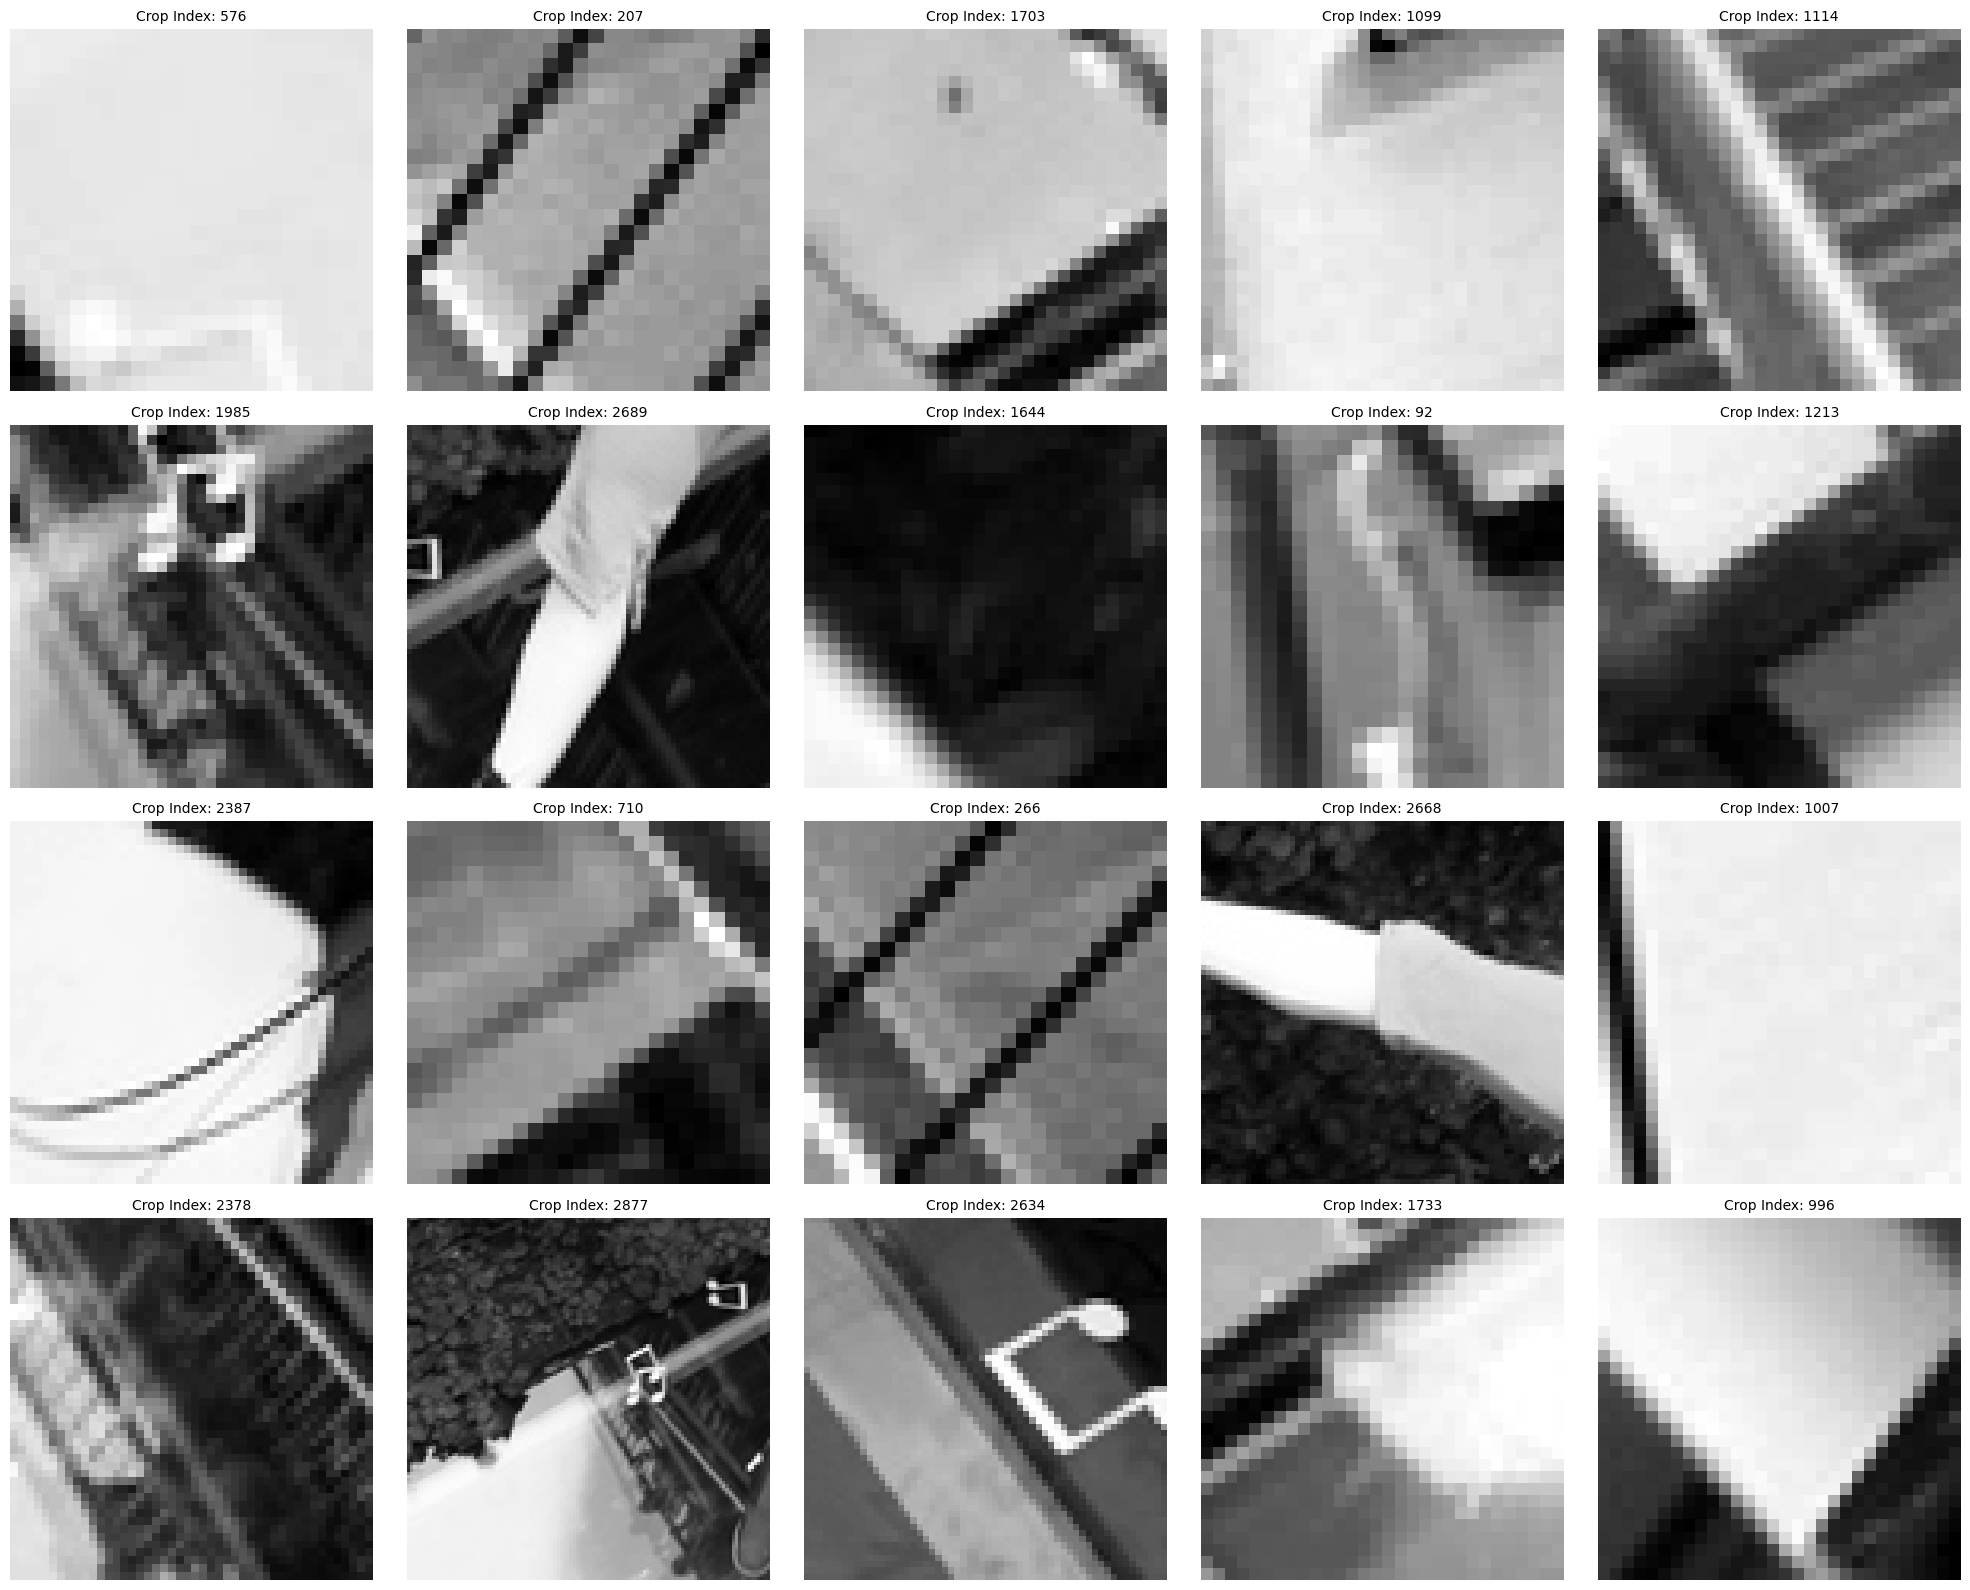

In [6]:
import numpy as np
import matplotlib.pyplot as plt


# rng = np.random.default_rng(CONFIG.seed)

# Get random indices instead of random crops
sample_indices = np.random.choice(len(crops), size=20, replace=False)
sample = [crops[i] for i in sample_indices]

def show_images(images, indices):
    fig, axes = plt.subplots(4, 5, figsize=(20, 16))
    for ax, img, crop_idx in zip(axes.flatten(), images, indices):
        ax.imshow(img, cmap='gray')
        ax.set_title(f'Crop Index: {crop_idx}', fontsize=10)
        ax.axis("off")

    plt.tight_layout()
    plt.show()

show_images([i['img'] for i in sample], sample_indices)